# KLA - Baseline NAFNet Training

Degraded Input -> Normalisation -> Degradataion Encoder -> NAFNet -> Charbonnier loss

In [ ]:
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.4'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
import sys
import time
import dataclasses
from pathlib import Path
from typing import Callable

import jax
import jax.numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
import grain
from flax import nnx
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


In [ ]:
TRAIN_PATH = "./train"
TEST_PATH = "./NoisyLR"

TRAIN_LR_PATH = os.path.join(TRAIN_PATH, "NoisyLR")
TEST_LR_PATH = TEST_PATH
TRAIN_GT_PATH = os.path.join(TRAIN_PATH, "GT")


In [ ]:
@dataclasses.dataclass
class TrainConfig:
    train_noisy_dir: str
    train_gt_dir: str
    batch_size: int = 8
    worker_count: int = 1
    seed: int = 42

    in_channels: int = 1
    out_channels: int = 1
    hidden_dim: int = 32
    num_blocks: int = 4
    upsample_scale: int = 2

    deg_hidden_dim: int = 16
    deg_embed_dim: int = 8

    normalization: str = "asinh"

    learning_rate: float = 1e-3
    weight_decay: float = 3e-4
    grad_clip_norm: float = 1.0

    num_epochs: int = 100
    val_split: float = 0.1

    ckpt_dir: str = "checkpoints"
    ckpt_every_epochs: int = 5
    max_to_keep: int = 5

    log_every_steps: int = 20
    loss_func: str = "Huber"


cfg = TrainConfig(
    train_noisy_dir=TRAIN_LR_PATH,
    train_gt_dir=TRAIN_GT_PATH,
    batch_size=16,
    hidden_dim=32,
    num_blocks=8,
    num_epochs=80,
    ckpt_dir="./checkpoints",
    ckpt_every_epochs=5,
)


In [ ]:
from dataloader import create_src_dataloader


In [ ]:
EPS = 1e-6


def zscore_normalize(x: jax.Array, axis=None, eps: float = EPS) -> jax.Array:
    mean = jnp.mean(x, axis=axis, keepdims=True)
    std = jnp.std(x, axis=axis, keepdims=True)
    return (x - mean) / (std + eps)


def zscore_denormalize(x_norm: jax.Array, mean: jax.Array, std: jax.Array, eps: float = EPS) -> jax.Array:
    return x_norm * (std + eps) + mean


def asinh_normalize(x: jax.Array, axis=None, eps: float = EPS) -> jax.Array:
    median = jnp.median(x, axis=axis, keepdims=True)
    q75 = jnp.quantile(x, 0.75, axis=axis, keepdims=True)
    q25 = jnp.quantile(x, 0.25, axis=axis, keepdims=True)
    iqr = q75 - q25
    return jnp.arcsinh((x - median) / (iqr + eps))


def asinh_denormalize(x_norm: jax.Array, median: jax.Array, iqr: jax.Array, eps: float = EPS) -> jax.Array:
    return jnp.sinh(x_norm) * (iqr + eps) + median


# Registry so the train script can select strategy by name from config,
# without importing every function individually.
NORMALIZERS: dict[str, Callable[..., jax.Array]] = {
    "zscore": zscore_normalize,
    "asinh": asinh_normalize,
    "none": lambda x, **kwargs: x,
}


def get_normalizer(name: str) -> Callable[..., jax.Array]:
    if name not in NORMALIZERS:
        raise ValueError(f"Unknown normalizer '{name}'. Options: {list(NORMALIZERS)}")
    return NORMALIZERS[name]


In [ ]:
from model_util import *
from train_utils import *


ModuleNotFoundError: No module named 'pix'

In [ ]:
# ── File listing + train/val split ──────────────────────────────────────

all_noisy = sorted(Path(cfg.train_noisy_dir).glob("*.npy"))
all_gt    = sorted(Path(cfg.train_gt_dir).glob("*.npy"))
assert len(all_noisy) == len(all_gt), (
    f"Mismatch: {len(all_noisy)} noisy files vs {len(all_gt)} GT files"
)

train_noisy, val_noisy, train_gt, val_gt = train_test_split(
    all_noisy, all_gt,
    test_size=cfg.val_split, random_state=cfg.seed,
)

# ── Build dataloaders ───────────────────────────────────────────────────

train_src, train_loader = create_src_dataloader(
    train_noisy, train_gt,
    batch_size=cfg.batch_size, worker_count=cfg.worker_count,
    seed=cfg.seed, shuffle=True, augment=True,
)

val_src, val_loader = create_src_dataloader(
    val_noisy, val_gt,
    batch_size=cfg.batch_size, worker_count=cfg.worker_count,
    seed=cfg.seed + 1, shuffle=False, augment=False,
)

train_steps_per_epoch = len(train_src) // cfg.batch_size
val_steps_per_epoch   = len(val_src) // cfg.batch_size

print(f"Train: {len(train_src)} samples → {train_steps_per_epoch} steps/epoch")
print(f"Val:   {len(val_src)} samples → {val_steps_per_epoch} steps/epoch")


Train: 2880 samples → 180 steps/epoch
Val:   320 samples → 20 steps/epoch


In [ ]:
def build_checkpoint_manager(ckpt_dir, max_to_keep=5):
    options = ocp.CheckpointManagerOptions(
        max_to_keep=max_to_keep,
        save_interval_steps=1,  
        create=True,
        enable_async_checkpointing=True,
    )
    ckpt_dir = Path(ckpt_dir).resolve()
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    return ocp.CheckpointManager(str(ckpt_dir), options=options)


def save_checkpoint(manager, step, model, optimizer, epoch, train_loss):
    _, model_state = nnx.split(model)
    _, opt_state = nnx.split(optimizer)
    metadata = {"epoch": epoch, "step": step, "train_loss": float(train_loss)}

    manager.save(
        step,
        args=ocp.args.Composite(
            model_state=ocp.args.StandardSave(model_state),
            opt_state=ocp.args.StandardSave(opt_state),
            metadata=ocp.args.JsonSave(metadata),
        ),
    )


def restore_checkpoint(manager, step, model, optimizer):
    _, abstract_model_state = nnx.split(nnx.eval_shape(lambda: model))
    _, abstract_opt_state = nnx.split(nnx.eval_shape(lambda: optimizer))

    restored = manager.restore(
        step,
        args=ocp.args.Composite(
            model_state=ocp.args.StandardRestore(abstract_model_state),
            opt_state=ocp.args.StandardRestore(abstract_opt_state),
            metadata=ocp.args.JsonRestore(),
        ),
    )
    nnx.update(model, restored.model_state)
    nnx.update(optimizer, restored.opt_state)
    return dict(restored.metadata)

In [ ]:

rngs = nnx.Rngs(cfg.seed)
model = RestorationPipeline_Wavelet(
    in_channels=cfg.in_channels, out_channels=cfg.out_channels, hidden_dim=cfg.hidden_dim,
    num_blocks=cfg.num_blocks, upsample_scale=cfg.upsample_scale,
    deg_hidden_dim=cfg.deg_hidden_dim, deg_embed_dim=cfg.deg_embed_dim, rngs=rngs,
)

warmup = 2000
total_train_steps = train_steps_per_epoch * cfg.num_epochs

schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=cfg.learning_rate,
    warmup_steps=warmup, decay_steps=total_train_steps - warmup, end_value=1e-6,
)

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(cfg.grad_clip_norm),
        optax.adamw(learning_rate=schedule, weight_decay=cfg.weight_decay),
    ),
    wrt=nnx.Param,
)

normalizer_fn = asinh_normalize

ckpt_manager = build_checkpoint_manager(cfg.ckpt_dir, max_to_keep=cfg.max_to_keep)
print(f"[hardware] backend={jax.default_backend()} devices={jax.devices()}")
print(f"[schedule] warmup={warmup}  total_steps={total_train_steps}")


[hardware] backend=gpu devices=[CudaDevice(id=0)]
[schedule] warmup=2000  total_steps=14400


In [ ]:
train_iter = iter(train_loader)
val_iter   = iter(val_loader)
global_step = 0

for epoch in range(cfg.num_epochs):
    epoch_start = time.time()

    # ── Train ─────────────────────────────────────────────────────────
    model.train()
    epoch_train_losses = []
    pbar = tqdm(range(train_steps_per_epoch), desc=f"Epoch {epoch:03d} [train]", leave=False)
    for step_in_epoch in pbar:
        raw_batch = to_device(next(train_iter))

        # --- preprocessing (outside JIT) ---
        noisy = raw_batch["noisy_lr"].astype(jnp.float32)

        gt    = raw_batch["gt"].astype(jnp.float32)
        x_norm = normalizer_fn(noisy, axis=(1, 2))

        loss = train_step(model, optimizer, x_norm, gt)
        epoch_train_losses.append(float(loss))
        global_step += 1

        pbar.set_postfix(loss=f"{float(loss):.5f}")

    train_loss_mean = float(np.mean(epoch_train_losses))

    # ── Validate ──────────────────────────────────────────────────────
    model.eval()
    epoch_val_losses = []
    pbar_val = tqdm(range(val_steps_per_epoch), desc=f"Epoch {epoch:03d} [val]  ", leave=False)
    for _ in pbar_val:
        raw_batch = to_device(next(val_iter))

        noisy = raw_batch["noisy_lr"].astype(jnp.float32)
        gt    = raw_batch["gt"].astype(jnp.float32)
        x_norm = normalizer_fn(noisy, axis=(1, 2))

        v_loss, _ = val_step(model, x_norm, gt)
        epoch_val_losses.append(float(v_loss))

        pbar_val.set_postfix(val_loss=f"{float(v_loss):.5f}")

    val_loss_mean = float(np.mean(epoch_val_losses))

    # ── Epoch summary ─────────────────────────────────────────────────
    epoch_time = time.time() - epoch_start
    print(
        f"[epoch {epoch:03d}] "
        f"train_loss={train_loss_mean:.5f}  "
        f"val_loss={val_loss_mean:.5f}  "
        f"time={epoch_time:.1f}s"
    )

    if (epoch + 1) % cfg.ckpt_every_epochs == 0 or epoch == cfg.num_epochs - 1:
        save_checkpoint(ckpt_manager, global_step, model, optimizer, epoch, train_loss_mean)
        print(f"  [checkpoint] saved at step {global_step} (epoch {epoch})")

ckpt_manager.wait_until_finished()
ckpt_manager.close()
print("[done] training complete.")


Epoch 000 [train]:   0%|          | 0/180 [00:00<?, ?it/s]

E0811 11:56:46.000241   17931 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Epoch 000 [val]  :   0%|          | 0/20 [00:00<?, ?it/s]

[epoch 000] train_loss=0.51835  val_loss=0.34800  time=27.3s


Epoch 001 [train]:   0%|          | 0/180 [00:00<?, ?it/s]

...

Epoch 078 [val]  :   0%|          | 0/20 [00:00<?, ?it/s]

[epoch 078] train_loss=0.05298  val_loss=0.05355  time=8.7s


Epoch 079 [train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 079 [val]  :   0%|          | 0/20 [00:00<?, ?it/s]

[epoch 079] train_loss=0.05331  val_loss=0.05355  time=8.5s
  [checkpoint] saved at step 14400 (epoch 79)
[done] training complete.


In [ ]:

from train_utils import metric_val_step
restore_checkpoint(ckpt_manager,step=14400,model=model,optimizer=optimizer)

model.eval()
final_metrics=[]
SSIM_metric=[]
PSNR_metric=[]
LPIPS_metric=[]
pbar_val = tqdm(range(val_steps_per_epoch), desc=f"Epoch {epoch:03d} [val]  ", leave=False)
for _ in pbar_val:
    raw_batch = to_device(next(val_iter))

    noisy = raw_batch["noisy_lr"].astype(jnp.float32)
    gt    = raw_batch["gt"].astype(jnp.float32)
    x_norm = normalizer_fn(noisy, axis=(1, 2))
    metrics, _ = metric_val_step(model, x_norm, gt)
    SSIM_metric.append(metrics[0])
    PSNR_metric.append(metrics[1])
    LPIPS_metric.append(metrics[2])
    final_metrics.append(metrics)

print(f"mean SSIM:{np.mean(SSIM_metric)}")
print(f"mean PSNR:{np.mean(PSNR_metric)}")
print(f"mean LPIPS:{np.mean(LPIPS_metric)}")


Epoch 079 [val]  :   0%|          | 0/20 [00:00<?, ?it/s]

mean SSIM:0.8944293856620789
mean PSNR:23.587520599365234
mean LPIPS:0.4339832663536072


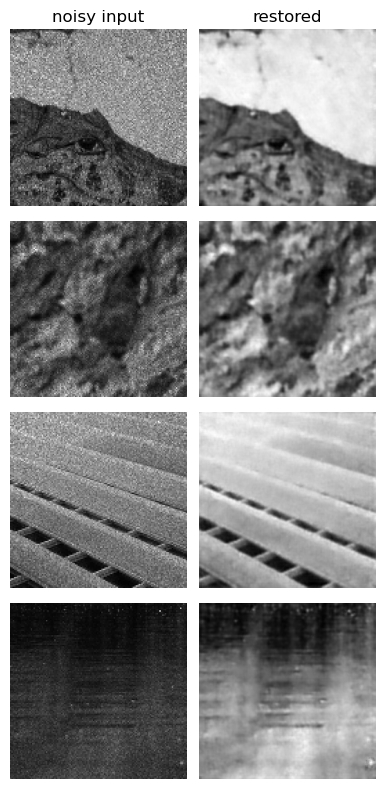

In [ ]:
import matplotlib.pyplot as plt

test_files = sorted(Path(TEST_LR_PATH).glob("*.npy"))[:8]
test_imgs = np.stack([np.load(f) for f in test_files])[..., None].astype(np.float32)  # (N,H,W,1)

# --- preprocessing (outside JIT) ---
noisy = to_device({"noisy_lr": test_imgs})["noisy_lr"]
x_norm = normalizer_fn(noisy, axis=(1, 2))

pred, _z_d = model(x_norm)

n = min(4, len(test_files))
fig, ax = plt.subplots(n, 2, figsize=(4, 2 * n))
for i in range(n):
    ax[i, 0].imshow(noisy[i, ..., 0], cmap="gray")
    ax[i, 1].imshow(pred[i, ..., 0], cmap="gray")
for a, t in zip(ax[0], ["noisy input", "restored"]):
    a.set_title(t)
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.show()


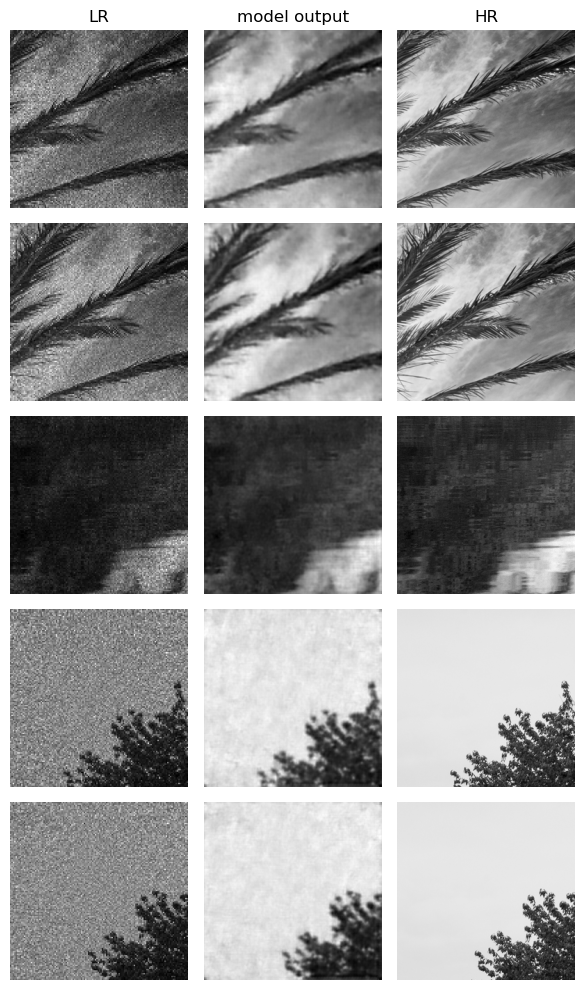

In [ ]:
lr_files = sorted(Path(TRAIN_LR_PATH).glob("*.npy"))[10:15]
gt_files = sorted(Path(TRAIN_GT_PATH).glob("*.npy"))[10:15]

lr_imgs = np.stack([np.load(f) for f in lr_files])[..., None].astype(np.float32)
hr_imgs = np.stack([np.load(f) for f in gt_files])[..., None].astype(np.float32)

# --- preprocessing (outside JIT) ---
lr = to_device({"noisy_lr": lr_imgs})["noisy_lr"]
hr = to_device({"gt": hr_imgs})["gt"]
x_norm = normalizer_fn(lr, axis=(1, 2))

pred, _z_d = model(x_norm)

n = len(lr_files)
fig, ax = plt.subplots(n, 3, figsize=(6, 2 * n))
for i in range(n):
    ax[i, 0].imshow(lr[i, ..., 0], cmap="gray")
    ax[i, 1].imshow(pred[i, ..., 0], cmap="gray")
    ax[i, 2].imshow(hr[i, ..., 0], cmap="gray")
for a, t in zip(ax[0], ["LR", "model output", "HR"]):
    a.set_title(t)
for a in ax.flat:
    a.axis("off")
plt.tight_layout()
plt.show()
